# Loan Portfolio & Credit Risk Analytics
### Data Analysis, SQL Analysis & Power BI Dashboard

This project analyzes a portfolio of 10,000 Lending Club loan records to understand loan distribution, portfolio characteristics, and credit risk patterns.

## Project Overview

### Objective
To analyze loan portfolio characteristics and identify patterns associated with credit risk.

### Key Areas of Analysis
- Portfolio size and loan amounts
- Loan purpose and credit grade
- Interest rates and outstanding balances
- Loan status distribution
- Credit risk categories
- Debt-to-income (DTI) patterns
- Monthly loan issuance

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- DuckDB / SQL
- Power BI

# 1. Data Loading

This section loads the original Lending Club loan dataset and verifies its dimensions and initial records.

## Data Loading

The original dataset is loaded into a Pandas DataFrame for analysis.

The dataset contains 10,000 loan records and 56 variables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loans_full_schema.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Rows: 10000
Columns: 56


,rownames,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [ ]:
print("All columns:\n")

for i, col in enumerate(df.columns, start=1):
    print(i, "-", col)

All columns:

1 - rownames
2 - emp_title
3 - emp_length
4 - state
5 - homeownership
6 - annual_income
7 - verified_income
8 - debt_to_income
9 - annual_income_joint
10 - verification_income_joint
11 - debt_to_income_joint
12 - delinq_2y
13 - months_since_last_delinq
14 - earliest_credit_line
15 - inquiries_last_12m
16 - total_credit_lines
17 - open_credit_lines
18 - total_credit_limit
19 - total_credit_utilized
20 - num_collections_last_12m
21 - num_historical_failed_to_pay
22 - months_since_90d_late
23 - current_accounts_delinq
24 - total_collection_amount_ever
25 - current_installment_accounts
26 - accounts_opened_24m
27 - months_since_last_credit_inquiry
28 - num_satisfactory_accounts
29 - num_accounts_120d_past_due
30 - num_accounts_30d_past_due
31 - num_active_debit_accounts
32 - total_debit_limit
33 - num_total_cc_accounts
34 - num_open_cc_accounts
35 - num_cc_carrying_balance
36 - num_mort_accounts
37 - account_never_delinq_percent
38 - tax_liens
39 - public_record_bankrupt
40 -

# 2. Initial Data Exploration

This section examines the structure, data types, basic statistics, and overall characteristics of the raw dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rownames                          10000 non-null  int64  
 1   emp_title                         9167 non-null   object 
 2   emp_length                        9183 non-null   float64
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    9976 non-null   float64
 8   annual_income_joint               1495 non-null   float64
 9   verification_income_joint         1455 non-null   object 
 10  debt_to_income_joint              1495 non-null   float64
 11  delinq_2y                         10000 non-null  int64  
 12  month

In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rownames,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
emp_title,9167,4741,manager,218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_length,9183.0,NaN,NaN,NaN,5.930306,3.703734,0.0,2.0,6.0,10.0,10.0
state,10000,50,CA,1330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homeownership,10000,3,MORTGAGE,4789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,10000.0,NaN,NaN,NaN,79222.148412,64734.290492,0.0,45000.0,65000.0,95000.0,2300000.0
verified_income,10000,3,Source Verified,4116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
debt_to_income,9976.0,NaN,NaN,NaN,19.308192,15.004851,0.0,11.0575,17.57,25.0025,469.09
annual_income_joint,1495.0,NaN,NaN,NaN,127914.571244,70168.375404,19200.0,86833.5,113000.0,151545.5,1100000.0
verification_income_joint,1455,3,Not Verified,611,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Data Quality Analysis

This section checks the dataset for missing values and duplicate records before performing data cleaning.

## Data Quality Analysis

Data quality is assessed by checking:

- Missing values
- Duplicate records
- Variable completeness
- Categorical distributions
- Potentially sparse variables

Highly incomplete joint-income variables are excluded from the main analysis because they contain missing values for most records.

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

display(missing)

,0
verification_income_joint,8545
annual_income_joint,8505
debt_to_income_joint,8505
months_since_90d_late,7715
months_since_last_delinq,5658
months_since_last_credit_inquiry,1271
emp_title,833
emp_length,817
num_accounts_120d_past_due,318
debt_to_income,24


In [ ]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

display(missing_percent)

,0
verification_income_joint,85.45
annual_income_joint,85.05
debt_to_income_joint,85.05
months_since_90d_late,77.15
months_since_last_delinq,56.58
months_since_last_credit_inquiry,12.71
emp_title,8.33
emp_length,8.17
num_accounts_120d_past_due,3.18
debt_to_income,0.24


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Loan Status:")
display(df["loan_status"].value_counts())

print("\nLoan Purpose:")
display(df["loan_purpose"].value_counts())

print("\nCredit Grade:")
display(df["grade"].value_counts().sort_index())

print("\nHomeownership:")
display(df["homeownership"].value_counts())

print("\nTerm:")
display(df["term"].value_counts())

Loan Status:


,count
loan_status,
Current,9375
Fully Paid,447
In Grace Period,67
Late (31-120 days),66
Late (16-30 days),38
Charged Off,7



Loan Purpose:


,count
loan_purpose,
debt_consolidation,5144
credit_card,2249
other,914
home_improvement,680
major_purchase,303
medical,162
house,151
car,131
small_business,125



Credit Grade:


,count
grade,
A,2459
B,3037
C,2653
D,1446
E,335
F,58
G,12



Homeownership:


,count
homeownership,
MORTGAGE,4789
RENT,3858
OWN,1353



Term:


,count
term,
36,6970
60,3030


In [ ]:
selected_columns = [
    "loan_amount",
    "term",
    "interest_rate",
    "installment",
    "grade",
    "sub_grade",
    "loan_status",
    "loan_purpose",
    "balance",
    "paid_total",
    "paid_principal",
    "paid_interest",
    "annual_income",
    "debt_to_income",
    "emp_length",
    "homeownership",
    "verified_income",
    "state",
    "delinq_2y",
    "inquiries_last_12m",
    "total_credit_lines",
    "open_credit_lines",
    "total_credit_limit",
    "total_credit_utilized"
]

In [ ]:
work_df = df[selected_columns].copy()

print("Working dataset shape:", work_df.shape)

display(work_df.head())

Working dataset shape: (10000, 24)


,loan_amount,term,interest_rate,installment,grade,sub_grade,loan_status,loan_purpose,balance,paid_total,...,emp_length,homeownership,verified_income,state,delinq_2y,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized
0,28000,60,14.07,652.53,C,C3,Current,moving,27015.86,1999.33,...,3.0,MORTGAGE,Verified,NJ,0,6,28,10,70795,38767
1,5000,36,12.61,167.54,C,C1,Current,debt_consolidation,4651.37,499.12,...,10.0,RENT,Not Verified,HI,0,1,30,14,28800,4321
2,2000,36,17.09,71.40,D,D1,Current,other,1824.63,281.80,...,3.0,RENT,Source Verified,WI,0,4,31,10,24193,16000
3,21600,36,6.72,664.19,A,A3,Current,debt_consolidation,18853.26,3312.89,...,1.0,RENT,Not Verified,PA,0,0,4,4,25400,4997
4,23000,36,14.07,786.87,C,C3,Current,credit_card,21430.15,2324.65,...,10.0,RENT,Verified,CA,0,7,22,16,69839,52722


In [ ]:
working_missing = work_df.isnull().sum().sort_values(ascending=False)

display(working_missing[working_missing > 0])

,0
emp_length,817
debt_to_income,24


In [ ]:
numeric_columns = [
    "loan_amount",
    "interest_rate",
    "installment",
    "balance",
    "paid_total",
    "paid_principal",
    "paid_interest",
    "annual_income",
    "debt_to_income",
    "delinq_2y",
    "inquiries_last_12m",
    "total_credit_lines",
    "open_credit_lines",
    "total_credit_limit",
    "total_credit_utilized"
]

work_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,10000.0,16361.922500,10301.956759,1000.00,8000.0000,14500.000,24000.0000,4.000000e+04
interest_rate,10000.0,12.427524,5.001105,5.31,9.4300,11.980,15.0500,3.094000e+01
installment,10000.0,476.205323,294.851627,30.75,256.0400,398.420,644.6900,1.566590e+03
balance,10000.0,14458.916610,9964.561865,0.00,6679.0650,12379.495,20690.1825,4.000000e+04
paid_total,10000.0,2494.234773,3958.230365,0.00,928.7000,1563.300,2616.0050,4.163044e+04
paid_principal,10000.0,1894.448466,3884.407175,0.00,587.1000,984.990,1694.5550,4.000000e+04
paid_interest,10000.0,599.666781,517.328062,0.00,221.7575,446.140,825.4200,4.216440e+03
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.000,95000.0000,2.300000e+06
debt_to_income,9976.0,19.308192,15.004851,0.00,11.0575,17.570,25.0025,4.690900e+02
delinq_2y,10000.0,0.216000,0.683660,0.00,0.0000,0.000,0.0000,1.300000e+01


In [ ]:
for col in numeric_columns:
    work_df[col] = work_df[col].fillna(work_df[col].median())

In [ ]:
categorical_columns = [
    "term",
    "grade",
    "sub_grade",
    "loan_status",
    "loan_purpose",
    "emp_length",
    "homeownership",
    "verified_income",
    "state"
]

for col in categorical_columns:
    work_df[col] = work_df[col].fillna("Unknown")

In [ ]:
print("Remaining missing values:")

remaining_missing = work_df.isnull().sum()
display(remaining_missing[remaining_missing > 0])

Remaining missing values:


,0


# 4. Data Cleaning & Feature Engineering

This section prepares the dataset for analysis by handling missing values, selecting relevant variables, and creating analytical features such as credit utilization, DTI groups, income groups, and risk categories.

In [ ]:
work_df["credit_utilization"] = np.where(
    work_df["total_credit_limit"] > 0,
    (work_df["total_credit_utilized"] / work_df["total_credit_limit"]) * 100,
    0
)

In [ ]:
display(
    work_df[
        ["total_credit_limit", "total_credit_utilized", "credit_utilization"]
    ].head(10)
)

,total_credit_limit,total_credit_utilized,credit_utilization
0,70795,38767,54.759517
1,28800,4321,15.003472
2,24193,16000,66.134832
3,25400,4997,19.673228
4,69839,52722,75.490772
5,42100,3898,9.258907
6,291852,18916,6.481367
7,342336,60805,17.761790
8,283190,69561,24.563367
9,33114,17768,53.657063


In [ ]:
work_df["dti_group"] = pd.cut(
    work_df["debt_to_income"],
    bins=[-np.inf, 10, 20, 30, 40, np.inf],
    labels=["0-10", "10-20", "20-30", "30-40", "40+"]
)

In [ ]:
display(work_df["dti_group"].value_counts().sort_index())

,count
dti_group,
0-10,2121
10-20,3812
20-30,2709
30-40,1020
40+,338


In [ ]:
work_df["income_group"] = pd.cut(
    work_df["annual_income"],
    bins=[0, 40000, 75000, 100000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

In [ ]:
display(work_df["income_group"].value_counts().sort_index())

,count
income_group,
Low,1969
Medium,4139
High,1767
Very High,2102


In [ ]:
display(work_df["loan_status"].value_counts())

,count
loan_status,
Current,9375
Fully Paid,447
In Grace Period,67
Late (31-120 days),66
Late (16-30 days),38
Charged Off,7


In [ ]:
problem_statuses = [
    "Charged Off",
    "Default",
    "Late (31-120 days)"
]

work_df["problem_loan"] = work_df["loan_status"].isin(problem_statuses).astype(int)

In [ ]:
display(work_df["problem_loan"].value_counts())

,count
problem_loan,
0,9927
1,73


In [ ]:
problem_rate = work_df["problem_loan"].mean() * 100

print(f"Problem Loan Rate: {problem_rate:.2f}%")

Problem Loan Rate: 0.73%


In [ ]:
print("Final working dataset:")
print("Rows:", work_df.shape[0])
print("Columns:", work_df.shape[1])

display(work_df.head())

Final working dataset:
Rows: 10000
Columns: 28


,loan_amount,term,interest_rate,installment,grade,sub_grade,loan_status,loan_purpose,balance,paid_total,...,delinq_2y,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,credit_utilization,dti_group,income_group,problem_loan
0,28000,60,14.07,652.53,C,C3,Current,moving,27015.86,1999.33,...,0,6,28,10,70795,38767,54.759517,10-20,High,0
1,5000,36,12.61,167.54,C,C1,Current,debt_consolidation,4651.37,499.12,...,0,1,30,14,28800,4321,15.003472,0-10,Low,0
2,2000,36,17.09,71.40,D,D1,Current,other,1824.63,281.80,...,0,4,31,10,24193,16000,66.134832,20-30,Low,0
3,21600,36,6.72,664.19,A,A3,Current,debt_consolidation,18853.26,3312.89,...,0,0,4,4,25400,4997,19.673228,10-20,Low,0
4,23000,36,14.07,786.87,C,C3,Current,credit_card,21430.15,2324.65,...,0,7,22,16,69839,52722,75.490772,40+,Low,0


In [ ]:
work_df.to_csv("loan_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# 5. Exploratory Data Analysis

This section explores the major characteristics of the loan portfolio, including loan purposes, credit grades, loan terms, interest rates, and loan status.

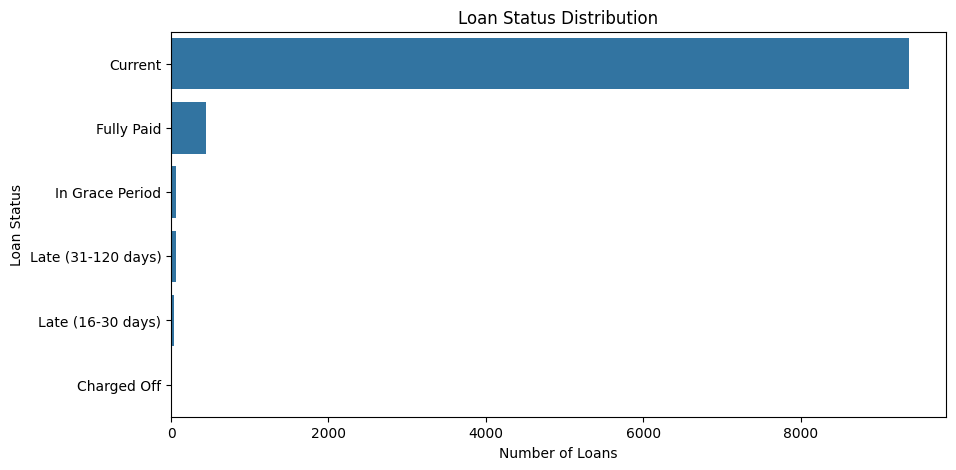

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=work_df,
    y="loan_status",
    order=work_df["loan_status"].value_counts().index
)

plt.title("Loan Status Distribution")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")
plt.show()

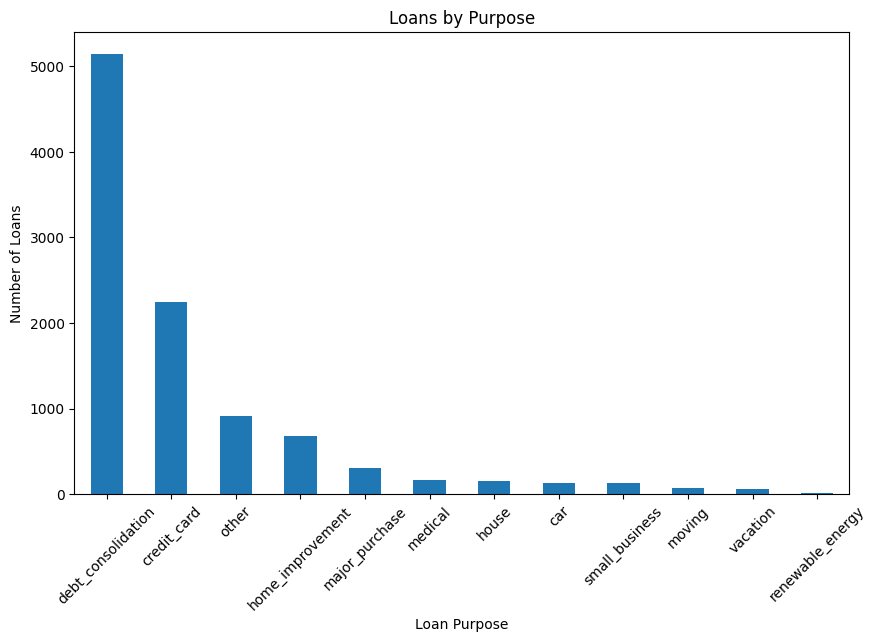

In [ ]:
plt.figure(figsize=(10, 6))

work_df["loan_purpose"].value_counts().plot(kind="bar")

plt.title("Loans by Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45)
plt.show()

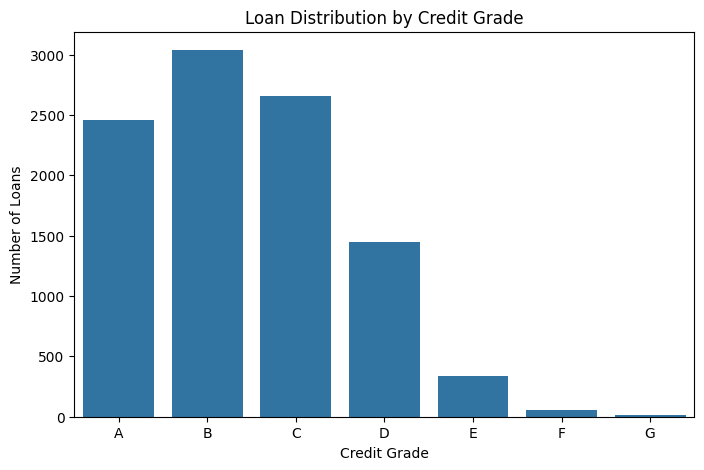

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=work_df,
    x="grade",
    order=sorted(work_df["grade"].unique())
)

plt.title("Loan Distribution by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Number of Loans")
plt.show()

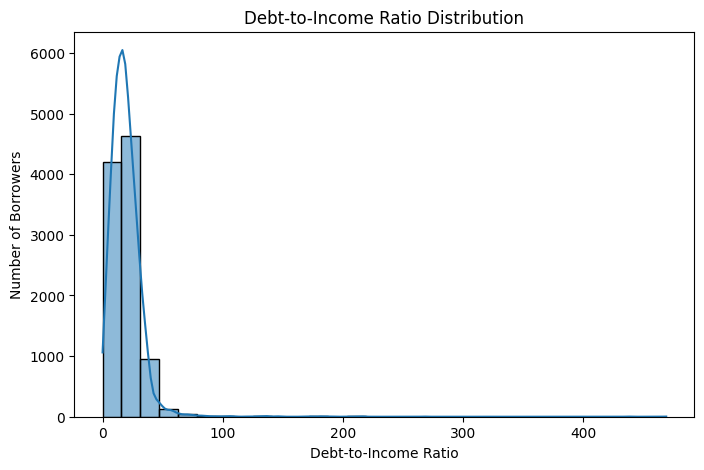

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    work_df["debt_to_income"],
    bins=30,
    kde=True
)

plt.title("Debt-to-Income Ratio Distribution")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Borrowers")
plt.show()

In [ ]:
# Add issue month for portfolio trend analysis
work_df["issue_month"] = df.loc[work_df.index, "issue_month"]

print(work_df["issue_month"].head())
print("\nUnique issue months:", work_df["issue_month"].nunique())

0    Mar-2018
1    Feb-2018
2    Feb-2018
3    Jan-2018
4    Mar-2018
Name: issue_month, dtype: object

Unique issue months: 3


In [ ]:
status_counts = work_df["loan_status"].value_counts()

display(status_counts)

,count
loan_status,
Current,9375
Fully Paid,447
In Grace Period,67
Late (31-120 days),66
Late (16-30 days),38
Charged Off,7


In [ ]:
status_percent = (
    work_df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(status_percent)

,proportion
loan_status,
Current,93.75
Fully Paid,4.47
In Grace Period,0.67
Late (31-120 days),0.66
Late (16-30 days),0.38
Charged Off,0.07


In [ ]:
status_summary = pd.DataFrame({
    "Loan Count": status_counts,
    "Percentage": status_percent
})

display(status_summary)

,Loan Count,Percentage
loan_status,,
Current,9375,93.75
Fully Paid,447,4.47
In Grace Period,67,0.67
Late (31-120 days),66,0.66
Late (16-30 days),38,0.38
Charged Off,7,0.07


In [ ]:
total_loans = len(work_df)
total_loan_amount = work_df["loan_amount"].sum()
total_outstanding = work_df["balance"].sum()
average_loan = work_df["loan_amount"].mean()
average_interest = work_df["interest_rate"].mean()
total_interest_paid = work_df["paid_interest"].sum()

print(f"Total Loans: {total_loans:,}")
print(f"Total Loan Amount: ${total_loan_amount:,.2f}")
print(f"Total Outstanding Balance: ${total_outstanding:,.2f}")
print(f"Average Loan Amount: ${average_loan:,.2f}")
print(f"Average Interest Rate: {average_interest:.2f}%")
print(f"Total Interest Paid: ${total_interest_paid:,.2f}")

Total Loans: 10,000
Total Loan Amount: $163,619,225.00
Total Outstanding Balance: $144,589,166.10
Average Loan Amount: $16,361.92
Average Interest Rate: 12.43%
Total Interest Paid: $5,996,667.81


### Loan Purpose Distribution

Loan purpose is examined to understand which purposes account for the largest share of the portfolio.

In [ ]:
purpose_summary = (
    work_df.groupby("loan_purpose")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Average_Loan=("loan_amount", "mean"),
        Average_Interest=("interest_rate", "mean")
    )
    .sort_values("Total_Loan_Amount", ascending=False)
)

display(purpose_summary)

,Loan_Count,Total_Loan_Amount,Average_Loan,Average_Interest
loan_purpose,,,,
debt_consolidation,5144,90767925,17645.397551,13.009541
credit_card,2249,34951225,15540.784793,11.432343
other,914,11819025,12931.099562,12.425766
home_improvement,680,11719225,17234.154412,11.620309
major_purchase,303,4752425,15684.570957,11.966271
house,151,2689275,17809.768212,11.369868
small_business,125,2477500,19820.000000,13.002560
medical,162,1836800,11338.271605,12.151173
car,131,1361250,10391.221374,12.038015


In [ ]:
grade_summary = (
    work_df.groupby("grade")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Average_Loan=("loan_amount", "mean"),
        Average_Interest=("interest_rate", "mean")
    )
    .sort_index()
)

display(grade_summary)

,Loan_Count,Total_Loan_Amount,Average_Loan,Average_Interest
grade,,,,
A,2459,37867450,15399.532330,6.742631
B,3037,49355200,16251.300626,10.524103
C,2653,44678275,16840.661515,14.176698
D,1446,24024175,16614.228907,19.113451
E,335,6117450,18261.044776,25.103403
F,58,1271525,21922.844828,29.401897
G,12,305150,25429.166667,30.802500


In [ ]:
risk_by_grade = (
    pd.crosstab(
        work_df["grade"],
        work_df["loan_status"],
        normalize="index"
    ) * 100
)

risk_by_grade = risk_by_grade.round(2)

display(risk_by_grade)

loan_status,Charged Off,Current,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
grade,,,,,,
A,0.08,95.20,4.03,0.41,0.12,0.16
B,0.07,95.36,3.56,0.36,0.23,0.43
C,0.04,92.99,5.05,0.72,0.45,0.75
D,0.14,91.49,5.12,1.24,0.69,1.31
E,0.00,86.87,8.06,2.39,0.90,1.79
F,0.00,81.03,6.90,1.72,3.45,6.90
G,0.00,83.33,8.33,0.00,8.33,0.00


In [ ]:
risk_by_dti = (
    pd.crosstab(
        work_df["dti_group"],
        work_df["loan_status"],
        normalize="index"
    ) * 100
)

display(risk_by_dti.round(2))

loan_status,Charged Off,Current,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
dti_group,,,,,,
0-10,0.09,92.31,5.23,0.75,0.52,1.08
10-20,0.03,93.97,4.77,0.52,0.29,0.42
20-30,0.11,93.95,4.13,0.66,0.41,0.74
30-40,0.10,94.61,3.33,0.88,0.39,0.69
40+,0.00,96.15,2.37,1.18,0.30,0.00


In [ ]:
risk_by_income = (
    pd.crosstab(
        work_df["income_group"],
        work_df["loan_status"],
        normalize="index"
    ) * 100
)

display(risk_by_income.round(2))

loan_status,Charged Off,Current,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
income_group,,,,,,
Low,0.05,94.21,3.81,0.56,0.51,0.86
Medium,0.10,94.13,4.37,0.56,0.31,0.53
High,0.00,93.04,4.81,0.91,0.45,0.79
Very High,0.10,93.24,4.95,0.76,0.33,0.62


In [ ]:
term_summary = (
    work_df.groupby("term")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Average_Loan=("loan_amount", "mean"),
        Average_Interest=("interest_rate", "mean")
    )
)

display(term_summary)

,Loan_Count,Total_Loan_Amount,Average_Loan,Average_Interest
term,,,,
36,6970,96258500,13810.401722,11.244927
60,3030,67360725,22231.262376,15.147888


# 6. Credit Risk Analysis

This section examines the distribution of the project-defined risk categories and their relationship with credit grade and debt-to-income groups.

In [ ]:
def classify_risk(status):
    if status in ["Charged Off", "Default"]:
        return "High Risk"
    elif status in ["Late (31-120 days)", "Late (16-30 days)"]:
        return "Medium Risk"
    else:
        return "Lower Risk"

work_df["risk_category"] = work_df["loan_status"].apply(classify_risk)

display(work_df["risk_category"].value_counts())

,count
risk_category,
Lower Risk,9889
Medium Risk,104
High Risk,7


In [ ]:
risk_percentage = (
    work_df["risk_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(risk_percentage)

,proportion
risk_category,
Lower Risk,98.89
Medium Risk,1.04
High Risk,0.07


In [ ]:
risk_grade_summary = pd.crosstab(
    work_df["grade"],
    work_df["risk_category"],
    normalize="index"
) * 100

display(risk_grade_summary.round(2))

risk_category,High Risk,Lower Risk,Medium Risk
grade,,,
A,0.08,99.63,0.28
B,0.07,99.28,0.66
C,0.04,98.76,1.21
D,0.14,97.86,2.01
E,0.00,97.31,2.69
F,0.00,89.66,10.34
G,0.00,91.67,8.33


In [ ]:
risk_dti_summary = pd.crosstab(
    work_df["dti_group"],
    work_df["risk_category"],
    normalize="index"
) * 100

display(risk_dti_summary.round(2))

risk_category,High Risk,Lower Risk,Medium Risk
dti_group,,,
0-10,0.09,98.30,1.60
10-20,0.03,99.27,0.71
20-30,0.11,98.74,1.14
30-40,0.10,98.82,1.08
40+,0.00,99.70,0.30


In [ ]:
risk_purpose_summary = pd.crosstab(
    work_df["loan_purpose"],
    work_df["risk_category"],
    normalize="index"
) * 100

display(risk_purpose_summary.round(2))

risk_category,High Risk,Lower Risk,Medium Risk
loan_purpose,,,
car,0.00,98.47,1.53
credit_card,0.04,99.33,0.62
debt_consolidation,0.04,98.97,0.99
home_improvement,0.29,98.53,1.18
house,0.66,96.03,3.31
major_purchase,0.00,98.35,1.65
medical,0.00,97.53,2.47
moving,0.00,97.10,2.90
other,0.11,98.69,1.20


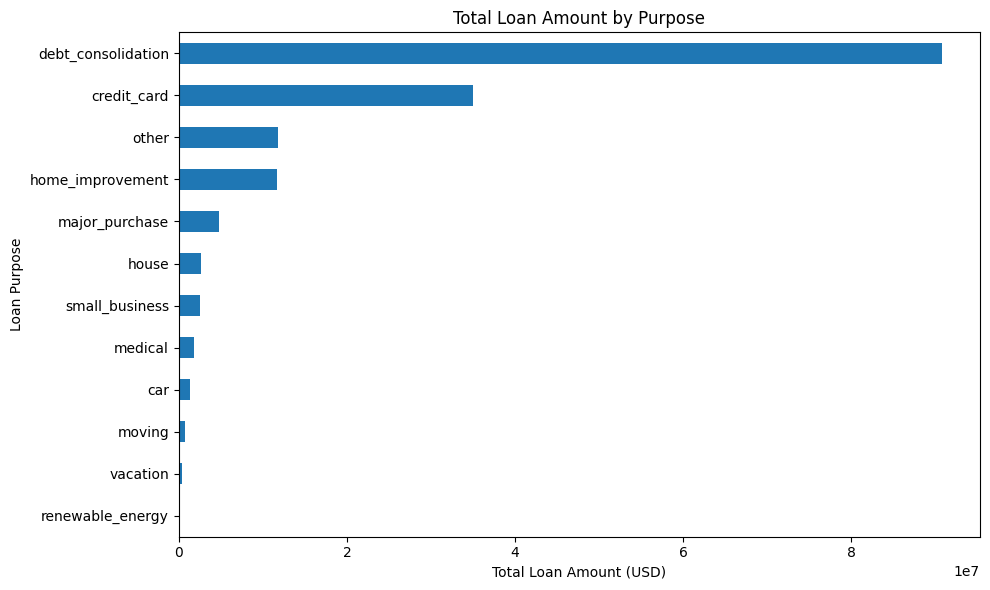

In [ ]:
plt.figure(figsize=(10, 6))

purpose_summary["Total_Loan_Amount"].sort_values().plot(kind="barh")

plt.title("Total Loan Amount by Purpose")
plt.xlabel("Total Loan Amount (USD)")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()

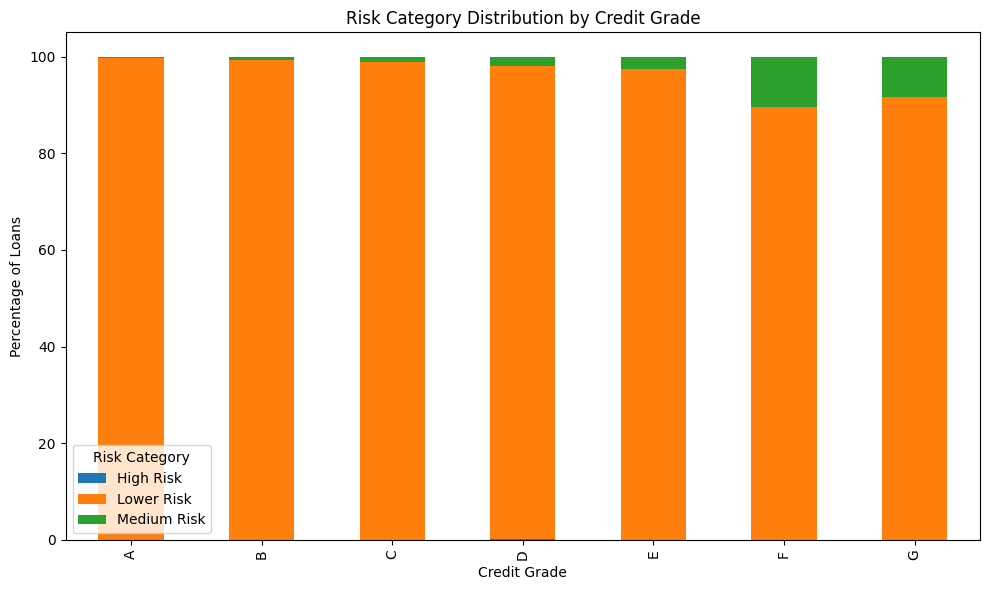

In [ ]:
risk_grade_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Risk Category Distribution by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Percentage of Loans")
plt.legend(title="Risk Category")
plt.tight_layout()
plt.show()

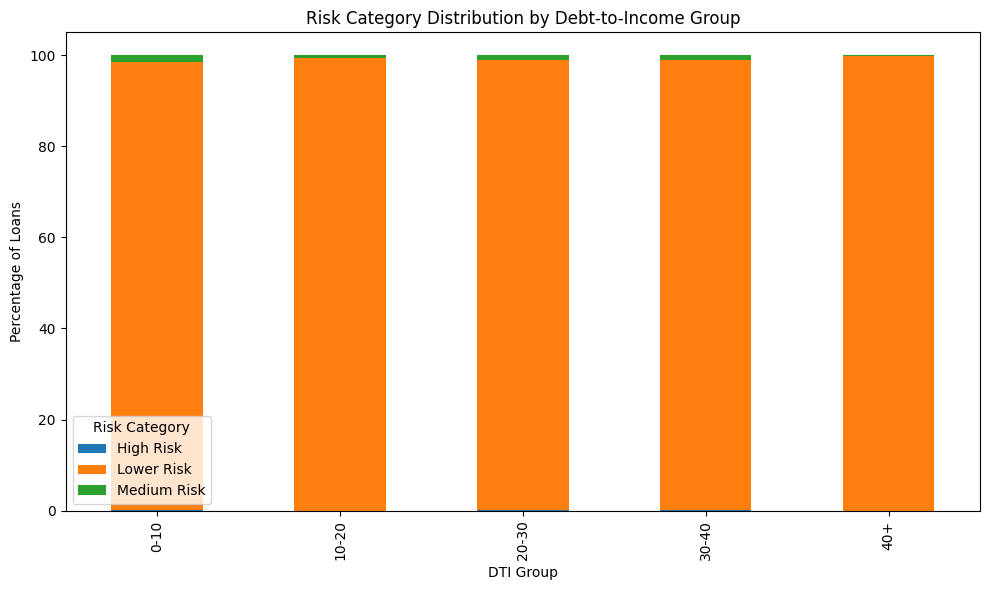

In [ ]:
risk_dti_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Risk Category Distribution by Debt-to-Income Group")
plt.xlabel("DTI Group")
plt.ylabel("Percentage of Loans")
plt.legend(title="Risk Category")
plt.tight_layout()
plt.show()

In [ ]:
print(work_df["issue_month"].unique())

['Mar-2018' 'Feb-2018' 'Jan-2018']


In [ ]:
monthly_loans = (
    work_df.groupby("issue_month")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum")
    )
    .reset_index()
)

display(monthly_loans.head())

,issue_month,Loan_Count,Total_Loan_Amount
0,Feb-2018,2988,49481550
1,Jan-2018,3395,54561925
2,Mar-2018,3617,59575750


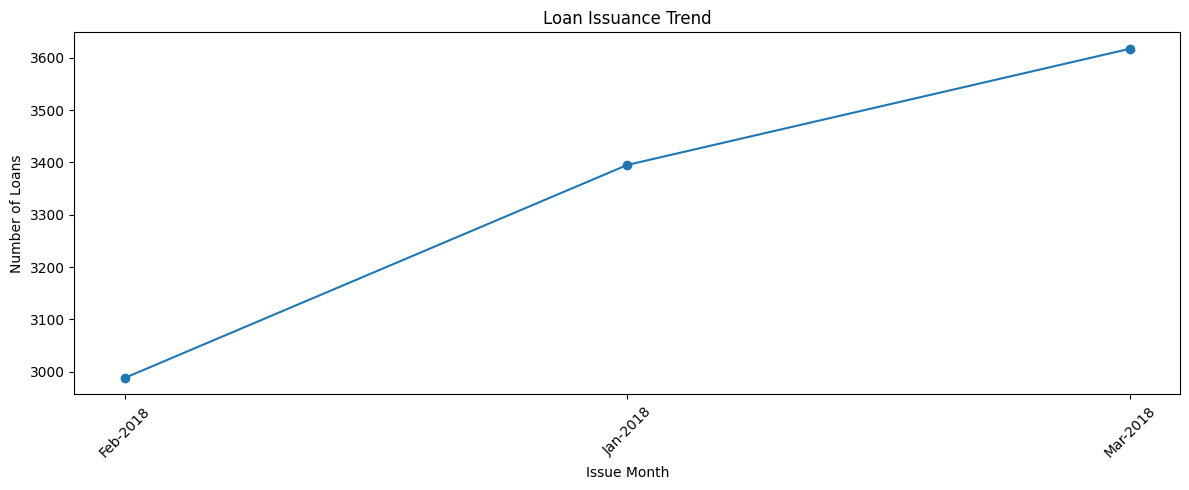

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_loans["issue_month"],
    monthly_loans["Loan_Count"],
    marker="o"
)

plt.title("Loan Issuance Trend")
plt.xlabel("Issue Month")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
work_df["risk_category"] = work_df["loan_status"].apply(
    lambda x: (
        "High Risk" if x in ["Charged Off", "Default"]
        else "Medium Risk" if x in ["Late (31-120 days)", "Late (16-30 days)"]
        else "No Current Problem"
    )
)

display(work_df["risk_category"].value_counts())

,count
risk_category,
No Current Problem,9889
Medium Risk,104
High Risk,7


In [ ]:
work_df["issue_date"] = pd.to_datetime(
    work_df["issue_month"],
    format="%b-%Y"
)

work_df["issue_month"] = work_df["issue_date"].dt.strftime("%b-%Y")

display(work_df[["issue_month", "issue_date"]].head())

,issue_month,issue_date
0,Mar-2018,2018-03-01
1,Feb-2018,2018-02-01
2,Feb-2018,2018-02-01
3,Jan-2018,2018-01-01
4,Mar-2018,2018-03-01


In [ ]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total Loans",
        "Total Loan Amount",
        "Outstanding Balance",
        "Average Loan Amount",
        "Average Interest Rate",
        "Total Interest Paid"
    ],
    "Value": [
        len(work_df),
        work_df["loan_amount"].sum(),
        work_df["balance"].sum(),
        work_df["loan_amount"].mean(),
        work_df["interest_rate"].mean(),
        work_df["paid_interest"].sum()
    ]
})

display(portfolio_summary)

,Metric,Value
0,Total Loans,1.000000e+04
1,Total Loan Amount,1.636192e+08
2,Outstanding Balance,1.445892e+08
3,Average Loan Amount,1.636192e+04
4,Average Interest Rate,1.242752e+01
5,Total Interest Paid,5.996668e+06


In [ ]:
risk_summary = (
    work_df.groupby("risk_category")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Outstanding_Balance=("balance", "sum"),
        Average_Interest=("interest_rate", "mean")
    )
)

risk_summary["Percentage_of_Loans"] = (
    risk_summary["Loan_Count"] / len(work_df) * 100
)

display(risk_summary.round(2))

,Loan_Count,Total_Loan_Amount,Outstanding_Balance,Average_Interest,Percentage_of_Loans
risk_category,,,,,
High Risk,7,88500,0.000000e+00,12.38,0.07
Medium Risk,104,1879000,1.822734e+06,16.64,1.04
No Current Problem,9889,161651725,1.427664e+08,12.38,98.89


In [ ]:
grade_analysis = (
    work_df.groupby("grade")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Outstanding_Balance=("balance", "sum"),
        Average_Loan=("loan_amount", "mean"),
        Average_Interest=("interest_rate", "mean")
    )
)

grade_analysis["Percentage_of_Loans"] = (
    grade_analysis["Loan_Count"] / len(work_df) * 100
)

display(grade_analysis.round(2))

,Loan_Count,Total_Loan_Amount,Outstanding_Balance,Average_Loan,Average_Interest,Percentage_of_Loans
grade,,,,,,
A,2459,37867450,32938246.47,15399.53,6.74,24.59
B,3037,49355200,43764409.05,16251.30,10.52,30.37
C,2653,44678275,39647349.01,16840.66,14.18,26.53
D,1446,24024175,21420548.92,16614.23,19.11,14.46
E,335,6117450,5380868.20,18261.04,25.10,3.35
F,58,1271525,1165343.66,21922.84,29.40,0.58
G,12,305150,272400.79,25429.17,30.80,0.12


In [ ]:
dti_analysis = (
    work_df.groupby("dti_group", observed=True)
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Outstanding_Balance=("balance", "sum"),
        Average_Interest=("interest_rate", "mean")
    )
)

dti_analysis["Percentage_of_Loans"] = (
    dti_analysis["Loan_Count"] / len(work_df) * 100
)

display(dti_analysis.round(2))

,Loan_Count,Total_Loan_Amount,Outstanding_Balance,Average_Interest,Percentage_of_Loans
dti_group,,,,,
0-10,2121,34093200,29520734.95,11.18,21.21
10-20,3812,61699525,54402942.62,11.97,38.12
20-30,2709,44536525,39715288.75,13.09,27.09
30-40,1020,16319025,14617920.84,14.46,10.20
40+,338,6970950,6332278.94,13.99,3.38


In [ ]:
purpose_analysis = (
    work_df.groupby("loan_purpose")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Outstanding_Balance=("balance", "sum"),
        Average_Loan=("loan_amount", "mean"),
        Average_Interest=("interest_rate", "mean")
    )
    .sort_values("Total_Loan_Amount", ascending=False)
)

display(purpose_analysis.round(2))

,Loan_Count,Total_Loan_Amount,Outstanding_Balance,Average_Loan,Average_Interest
loan_purpose,,,,,
debt_consolidation,5144,90767925,80496048.30,17645.40,13.01
credit_card,2249,34951225,31139677.18,15540.78,11.43
other,914,11819025,10231809.16,12931.10,12.43
home_improvement,680,11719225,10333654.19,17234.15,11.62
major_purchase,303,4752425,4078480.98,15684.57,11.97
house,151,2689275,2340264.63,17809.77,11.37
small_business,125,2477500,2205848.06,19820.00,13.00
medical,162,1836800,1474723.59,11338.27,12.15
car,131,1361250,1224529.81,10391.22,12.04


In [ ]:
monthly_analysis = (
    work_df.groupby("issue_date")
    .agg(
        Loan_Count=("loan_amount", "count"),
        Total_Loan_Amount=("loan_amount", "sum"),
        Outstanding_Balance=("balance", "sum")
    )
    .reset_index()
    .sort_values("issue_date")
)

display(monthly_analysis)

,issue_date,Loan_Count,Total_Loan_Amount,Outstanding_Balance
0,2018-01-01,3395,54561925,46466402.10
1,2018-02-01,2988,49481550,43598652.78
2,2018-03-01,3617,59575750,54524111.22


In [ ]:
risk_grade = pd.crosstab(
    work_df["grade"],
    work_df["risk_category"],
    normalize="index"
) * 100

risk_grade = risk_grade.round(2)

display(risk_grade)

risk_category,High Risk,Medium Risk,No Current Problem
grade,,,
A,0.08,0.28,99.63
B,0.07,0.66,99.28
C,0.04,1.21,98.76
D,0.14,2.01,97.86
E,0.00,2.69,97.31
F,0.00,10.34,89.66
G,0.00,8.33,91.67


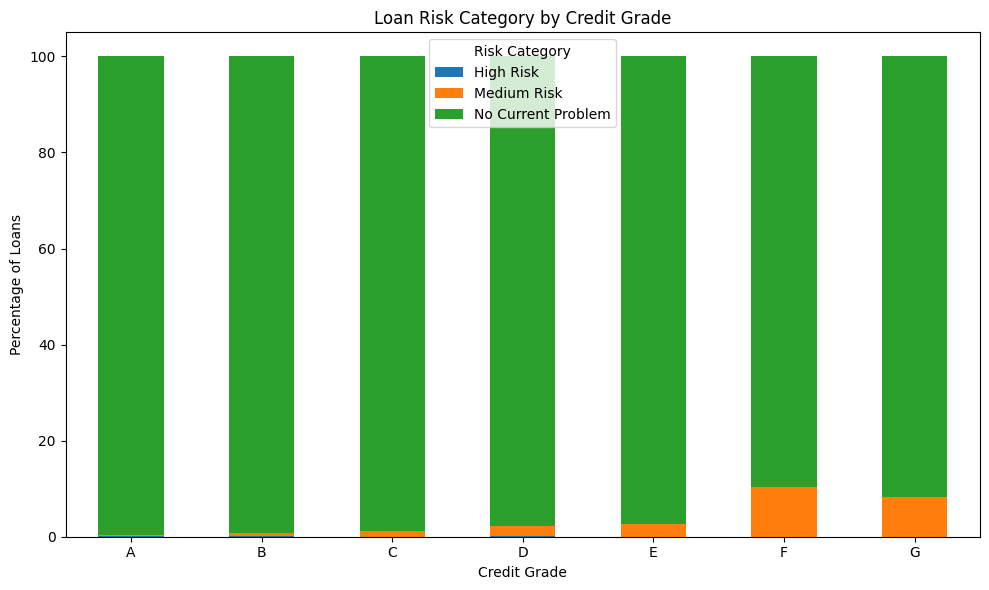

In [ ]:
risk_grade.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Loan Risk Category by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Percentage of Loans")
plt.legend(title="Risk Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
risk_dti = pd.crosstab(
    work_df["dti_group"],
    work_df["risk_category"],
    normalize="index"
) * 100

risk_dti = risk_dti.round(2)

display(risk_dti)

risk_category,High Risk,Medium Risk,No Current Problem
dti_group,,,
0-10,0.09,1.60,98.30
10-20,0.03,0.71,99.27
20-30,0.11,1.14,98.74
30-40,0.10,1.08,98.82
40+,0.00,0.30,99.70


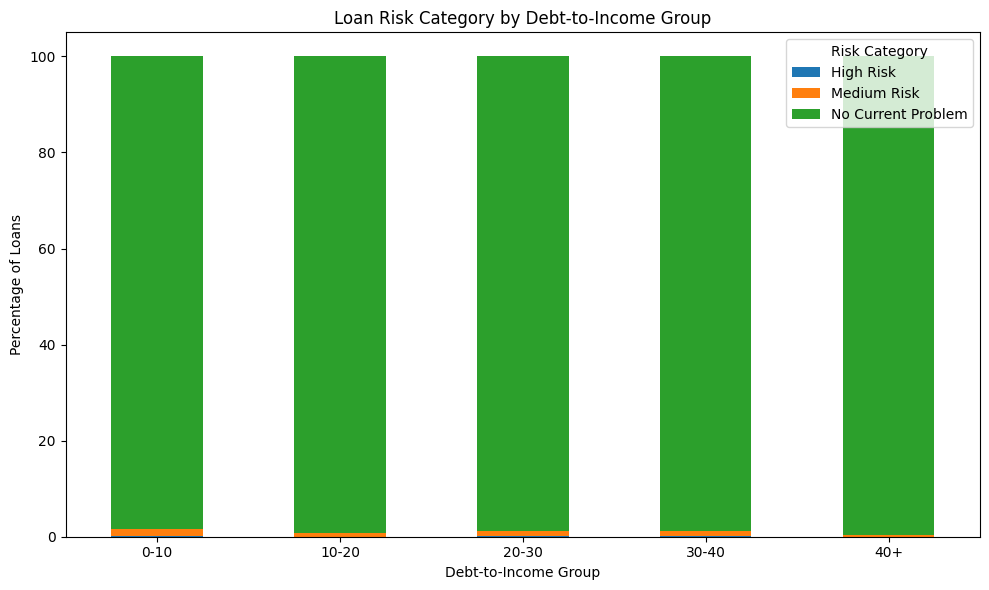

In [ ]:
risk_dti.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Loan Risk Category by Debt-to-Income Group")
plt.xlabel("Debt-to-Income Group")
plt.ylabel("Percentage of Loans")
plt.legend(title="Risk Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
work_df.to_csv(
    "loan_portfolio_final.csv",
    index=False
)

print("Final dataset saved as loan_portfolio_final.csv")
print("Rows:", len(work_df))
print("Columns:", len(work_df.columns))

Final dataset saved as loan_portfolio_final.csv
Rows: 10000
Columns: 31


# 7. SQL Analysis

SQL queries are used to independently summarize the portfolio and analyze loan distribution and credit risk using DuckDB.

## SQL Analysis

SQL is used to perform portfolio-level analysis on the cleaned loan dataset.

The analysis covers:

- Overall portfolio metrics
- Loan purpose
- Credit grade
- Loan status
- Risk category
- Risk distribution by credit grade
- Risk distribution by DTI group
- Monthly portfolio activity

DuckDB is used to execute SQL queries directly in the Colab environment.

In [ ]:
!pip -q install duckdb

In [ ]:
import duckdb

con = duckdb.connect()

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE loans AS
SELECT *
FROM read_csv_auto('loan_portfolio_final.csv')
""")

print("Loan table created successfully.")

Loan table created successfully.


In [ ]:
con.execute("""
SELECT COUNT(*) AS total_rows
FROM loans
""").df()

,total_rows
0,10000


In [ ]:
con.execute("""
DESCRIBE loans
""").df()

,column_name,column_type,null,key,default,extra
0,loan_amount,BIGINT,YES,None,None,None
1,term,BIGINT,YES,None,None,None
2,interest_rate,DOUBLE,YES,None,None,None
3,installment,DOUBLE,YES,None,None,None
4,grade,VARCHAR,YES,None,None,None
5,sub_grade,VARCHAR,YES,None,None,None
6,loan_status,VARCHAR,YES,None,None,None
7,loan_purpose,VARCHAR,YES,None,None,None
8,balance,DOUBLE,YES,None,None,None
9,paid_total,DOUBLE,YES,None,None,None


In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_loans,
    ROUND(SUM(loan_amount), 2) AS total_loan_amount,
    ROUND(SUM(balance), 2) AS outstanding_balance,
    ROUND(AVG(loan_amount), 2) AS average_loan_amount,
    ROUND(AVG(interest_rate), 2) AS average_interest_rate,
    ROUND(SUM(paid_interest), 2) AS total_interest_paid
FROM loans
""").df()

,total_loans,total_loan_amount,outstanding_balance,average_loan_amount,average_interest_rate,total_interest_paid
0,10000,163619225.0,144589166.1,16361.92,12.43,5996667.81


In [ ]:
con.execute("""
SELECT
    loan_purpose,
    COUNT(*) AS loan_count,
    ROUND(SUM(loan_amount), 2) AS total_loan_amount,
    ROUND(AVG(loan_amount), 2) AS average_loan_amount
FROM loans
GROUP BY loan_purpose
ORDER BY total_loan_amount DESC
""").df()

,loan_purpose,loan_count,total_loan_amount,average_loan_amount
0,debt_consolidation,5144,90767925.0,17645.40
1,credit_card,2249,34951225.0,15540.78
2,other,914,11819025.0,12931.10
3,home_improvement,680,11719225.0,17234.15
4,major_purchase,303,4752425.0,15684.57
5,house,151,2689275.0,17809.77
6,small_business,125,2477500.0,19820.00
7,medical,162,1836800.0,11338.27
8,car,131,1361250.0,10391.22
9,moving,69,682675.0,9893.84


In [ ]:
con.execute("""
SELECT
    grade,
    COUNT(*) AS loan_count,
    ROUND(SUM(loan_amount), 2) AS total_loan_amount,
    ROUND(AVG(interest_rate), 2) AS average_interest_rate,
    ROUND(AVG(loan_amount), 2) AS average_loan_amount
FROM loans
GROUP BY grade
ORDER BY grade
""").df()

,grade,loan_count,total_loan_amount,average_interest_rate,average_loan_amount
0,A,2459,37867450.0,6.74,15399.53
1,B,3037,49355200.0,10.52,16251.30
2,C,2653,44678275.0,14.18,16840.66
3,D,1446,24024175.0,19.11,16614.23
4,E,335,6117450.0,25.10,18261.04
5,F,58,1271525.0,29.40,21922.84
6,G,12,305150.0,30.80,25429.17


In [ ]:
con.execute("""
SELECT
    loan_status,
    COUNT(*) AS loan_count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM loans),
        2
    ) AS percentage_of_loans,
    ROUND(SUM(balance), 2) AS outstanding_balance
FROM loans
GROUP BY loan_status
ORDER BY loan_count DESC
""").df()

,loan_status,loan_count,percentage_of_loans,outstanding_balance
0,Current,9375,93.75,1.415895e+08
1,Fully Paid,447,4.47,0.000000e+00
2,In Grace Period,67,0.67,1.176944e+06
3,Late (31-120 days),66,0.66,1.214912e+06
4,Late (16-30 days),38,0.38,6.078220e+05
5,Charged Off,7,0.07,0.000000e+00


In [ ]:
con.execute("""
SELECT
    loan_status,
    COUNT(*) AS loan_count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM loans),
        2
    ) AS percentage_of_loans,
    ROUND(SUM(balance), 2) AS outstanding_balance
FROM loans
GROUP BY loan_status
ORDER BY loan_count DESC
""").df()

,loan_status,loan_count,percentage_of_loans,outstanding_balance
0,Current,9375,93.75,1.415895e+08
1,Fully Paid,447,4.47,0.000000e+00
2,In Grace Period,67,0.67,1.176944e+06
3,Late (31-120 days),66,0.66,1.214912e+06
4,Late (16-30 days),38,0.38,6.078220e+05
5,Charged Off,7,0.07,0.000000e+00


In [ ]:
con.execute("""
SELECT
    grade,
    risk_category,
    COUNT(*) AS loan_count,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY grade),
        2
    ) AS percentage_within_grade
FROM loans
GROUP BY grade, risk_category
ORDER BY grade, risk_category
""").df()

,grade,risk_category,loan_count,percentage_within_grade
0,A,High Risk,2,0.08
1,A,Medium Risk,7,0.28
2,A,No Current Problem,2450,99.63
3,B,High Risk,2,0.07
4,B,Medium Risk,20,0.66
5,B,No Current Problem,3015,99.28
6,C,High Risk,1,0.04
7,C,Medium Risk,32,1.21
8,C,No Current Problem,2620,98.76
9,D,High Risk,2,0.14


In [ ]:
con.execute("""
SELECT
    dti_group,
    risk_category,
    COUNT(*) AS loan_count,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY dti_group),
        2
    ) AS percentage_within_dti
FROM loans
GROUP BY dti_group, risk_category
ORDER BY dti_group, risk_category
""").df()

,dti_group,risk_category,loan_count,percentage_within_dti
0,0-10,High Risk,2,0.09
1,0-10,Medium Risk,34,1.60
2,0-10,No Current Problem,2085,98.30
3,10-20,High Risk,1,0.03
4,10-20,Medium Risk,27,0.71
5,10-20,No Current Problem,3784,99.27
6,20-30,High Risk,3,0.11
7,20-30,Medium Risk,31,1.14
8,20-30,No Current Problem,2675,98.74
9,30-40,High Risk,1,0.10


In [ ]:
con.execute("""
SELECT
    dti_group,
    risk_category,
    COUNT(*) AS loan_count,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY dti_group),
        2
    ) AS percentage_within_dti
FROM loans
GROUP BY dti_group, risk_category
ORDER BY dti_group, risk_category
""").df()

,dti_group,risk_category,loan_count,percentage_within_dti
0,0-10,High Risk,2,0.09
1,0-10,Medium Risk,34,1.60
2,0-10,No Current Problem,2085,98.30
3,10-20,High Risk,1,0.03
4,10-20,Medium Risk,27,0.71
5,10-20,No Current Problem,3784,99.27
6,20-30,High Risk,3,0.11
7,20-30,Medium Risk,31,1.14
8,20-30,No Current Problem,2675,98.74
9,30-40,High Risk,1,0.10


### SQL Analysis Summary

SQL analysis was used to independently summarize the portfolio and validate key findings obtained through Python.

The queries demonstrate:

- Aggregation using COUNT, SUM and AVG
- GROUP BY analysis
- Sorting and filtering
- Window functions
- Risk segmentation
- Monthly portfolio analysis

In [ ]:
%%writefile loan_analysis.sql

-- =========================================================
-- LOAN PORTFOLIO & CREDIT RISK ANALYTICS
-- SQL Analysis using DuckDB
-- Dataset: loan_portfolio_final.csv
-- =========================================================


-- =========================================================
-- 1. OVERALL PORTFOLIO KPIs
-- =========================================================

SELECT
    COUNT(*) AS total_loans,
    SUM(loan_amount) AS total_loan_amount,
    SUM(balance) AS outstanding_balance,
    AVG(loan_amount) AS average_loan,
    AVG(interest_rate) AS average_interest_rate,
    SUM(paid_interest) AS total_interest_paid
FROM loans;


-- =========================================================
-- 2. LOAN PURPOSE ANALYSIS
-- =========================================================

SELECT
    loan_purpose,
    COUNT(*) AS total_loans,
    SUM(loan_amount) AS total_loan_amount,
    AVG(loan_amount) AS average_loan
FROM loans
GROUP BY loan_purpose
ORDER BY total_loan_amount DESC;


-- =========================================================
-- 3. CREDIT GRADE ANALYSIS
-- =========================================================

SELECT
    grade,
    COUNT(*) AS total_loans,
    SUM(loan_amount) AS total_loan_amount,
    AVG(interest_rate) AS average_interest_rate
FROM loans
GROUP BY grade
ORDER BY grade;


-- =========================================================
-- 4. LOAN STATUS DISTRIBUTION
-- =========================================================

SELECT
    loan_status,
    COUNT(*) AS total_loans,
    SUM(loan_amount) AS total_loan_amount
FROM loans
GROUP BY loan_status
ORDER BY total_loans DESC;


-- =========================================================
-- 5. RISK CATEGORY ANALYSIS
-- =========================================================

SELECT
    risk_category,
    COUNT(*) AS total_loans,
    SUM(loan_amount) AS total_loan_amount
FROM loans
GROUP BY risk_category
ORDER BY total_loans DESC;


-- =========================================================
-- 6. RISK CATEGORY BY CREDIT GRADE
-- =========================================================

SELECT
    grade,
    risk_category,
    COUNT(*) AS total_loans,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY grade),
        2
    ) AS percentage_within_grade
FROM loans
GROUP BY grade, risk_category
ORDER BY grade, risk_category;


-- =========================================================
-- 7. RISK BY DTI GROUP
-- =========================================================

SELECT
    dti_group,
    risk_category,
    COUNT(*) AS total_loans,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY dti_group),
        2
    ) AS percentage_within_dti
FROM loans
GROUP BY dti_group, risk_category
ORDER BY dti_group, risk_category;


-- =========================================================
-- 8. MONTHLY PORTFOLIO ANALYSIS
-- =========================================================

SELECT
    issue_month,
    COUNT(*) AS total_loans,
    SUM(loan_amount) AS total_loan_amount,
    AVG(loan_amount) AS average_loan
FROM loans
GROUP BY issue_month
ORDER BY MIN(issue_date);

Writing loan_analysis.sql


# 8. Key Findings & Business Insights

## Key Findings

- The dataset contains 10,000 loan records.
- The total loan portfolio is approximately $163.62 million.
- Debt consolidation represents the largest loan-purpose segment by loan amount.
- Credit grades A, B, and C account for the majority of loans.
- Most loans are currently classified as Current.
- Higher-risk categories represent a relatively small portion of the overall portfolio.
- The dataset contains loan issuance records for January, February, and March 2018.